# *Populus* и лексика человеческих общностей у Августина
## Ноутбук 2. Проверки устойчивости

Ноутбук проверяет, зависит ли основная структура сети от технических решений, принятых в основном анализе. Результаты сведены в табл. П2 Приложения и кратко изложены в разделе 4 статьи.

| Раздел ноутбука | Что проверяется | Где в статье |
| --- | --- | --- |
| 4. Число соседей и повторные запуски | сохраняется ли группа *populus – gens – natio – plebs* при N = 10, 15, 20 и 50 запусках алгоритма Лейдена | разд. 4; табл. П2 |
| 5. Следующий порог | что отделяется от сети при θ = 0,48 | разд. 4; табл. П2 |
| 6. UMAP и HDBSCAN: одна проекция | наглядное сопоставление двух группировок | рис. 4 |
| 7. UMAP и HDBSCAN: 120 проекций | не случайна ли картина одной проекции | разд. 4; табл. П2 |
| 8. Итог | сводная таблица | табл. П2 |

**Как запускать.** Выполните ячейки по порядку. Раздел 7 занимает несколько минут.

**Замечание о воспроизводимости.** Результат UMAP может немного различаться в зависимости от версии библиотек и платформы: число кластеров на рис. 4 при повторном запуске может отличаться на несколько единиц. Выводы статьи опираются на многократную проверку раздела 7, которая от этого не зависит.

## 1. Подготовка среды

In [1]:
import importlib.util, subprocess, sys

REQUIRED = {"gensim": "gensim", "igraph": "igraph", "leidenalg": "leidenalg",
            "seaborn": "seaborn", "umap": "umap-learn"}
missing = [pkg for module, pkg in REQUIRED.items() if importlib.util.find_spec(module) is None]

if missing:
    print("Устанавливаются библиотеки:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("Все необходимые библиотеки уже установлены.")

Все необходимые библиотеки уже установлены.


## 2. Параметры и загрузка модели

Параметры основной сети совпадают с первым ноутбуком. Модель загружается и проверяется так же.

In [2]:
import hashlib, itertools, os, urllib.request, warnings

# Технические предупреждения библиотек UMAP и scikit-learn на результат не влияют
warnings.filterwarnings("ignore", message="IProgress not found")
warnings.filterwarnings("ignore", message="n_jobs value")
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns
import igraph as ig
import leidenalg
import umap
from gensim.models import Word2Vec
from sklearn.cluster import HDBSCAN
from sklearn.manifold import trustworthiness
from sklearn.metrics import homogeneity_completeness_v_measure, silhouette_score
from IPython.display import display, Markdown

# --- Параметры основной сети ---------------------------------------------
SEED = 42
BASE_TOP_N = 15                           # число соседей в основной сети
BASE_THRESHOLD = 0.47                     # порог основной сети
THRESHOLD_GRID = np.round(np.arange(0.30, 0.801, 0.01), 2)

DESIGNATIONS = ["populus", "plebs", "gens", "natio", "multitudo", "congregatio",
                "turba", "uulgus", "ciuitas", "societas", "ecclesia"]
LAW = ["ius", "iustitia"]
LOVE_AND_CONCORD = ["amor", "caritas", "dilectio", "concordia", "pax"]
TARGET_TERMS = DESIGNATIONS + LAW + LOVE_AND_CONCORD

# --- Параметры проверок -----------------------------------------------------
TOP_N_VALUES = [10, 15, 20]               # проверка 1: число соседей
N_LEIDEN_RUNS = 50                        # проверка 1: запуски алгоритма Лейдена
UMAP_NEIGHBORS = [10, 15, 30]             # проверка 4: параметры UMAP
UMAP_MIN_DIST = [0.1, 0.3]
UMAP_SEEDS = 20                           # случайных инициализаций на сочетание
HDBSCAN_MIN_CLUSTER = [3, 5]              # минимальный размер кластера HDBSCAN
HDBSCAN_MIN_SAMPLES = 2
N_PERMUTATIONS = 1000                     # перестановки для силуэта

# Леммы, отделение которых от populus проверяется
SEPARATE_FROM_POPULUS = ["ius", "iustitia", "amor", "caritas", "dilectio",
                         "concordia", "pax", "ecclesia", "societas"]

# --- Модель и рисунки -------------------------------------------------------
MODEL_URL = "https://github.com/eehvrangbaek/aug_will_love/raw/main/dat/word2vec.model"
MODEL_FILE = "word2vec.model"
MODEL_SHA256 = "a3a336148d8dbfa53778c3ea911aa285797b7e3902acba35edde98bedf6ea105"
FIG_DIR, FIG_DPI = "figures", 300
os.makedirs(FIG_DIR, exist_ok=True)

sns.set_style("white")
plt.rcParams.update({"figure.dpi": 120, "font.family": "DejaVu Sans", "font.size": 12,
                     "axes.titlesize": 15, "figure.facecolor": "white",
                     "savefig.facecolor": "white"})
np.random.seed(SEED)

if not os.path.exists(MODEL_FILE):
    print("Загружается модель из репозитория разработчиков…")
    urllib.request.urlretrieve(MODEL_URL, MODEL_FILE)
with open(MODEL_FILE, "rb") as f:
    if hashlib.sha256(f.read()).hexdigest() != MODEL_SHA256:
        raise ValueError("Контрольная сумма не совпадает: это другая версия модели.")

wv = Word2Vec.load(MODEL_FILE).wv
print(f"Модель загружена: {len(wv)} лемм, векторы размерности {wv.vector_size}")

Модель загружена: 9563 лемм, векторы размерности 50


## 3. Вспомогательные функции

Все функции ноутбука собраны в одной ячейке. Её достаточно выполнить.

In [3]:
def save_figure(fig, name):
    # Показывает рисунок в ноутбуке и сохраняет его в PNG.
    path = os.path.join(FIG_DIR, name + ".png")
    fig.savefig(path, dpi=FIG_DPI, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)
    print("Сохранено:", path)


def network_lemmas(top_n):
    # Целевые леммы и их top_n ближайших соседей — узлы сети.
    lemmas = set(TARGET_TERMS)
    for term in TARGET_TERMS:
        lemmas.update(w for w, _ in wv.most_similar(term, topn=top_n))
    return sorted(lemmas)


def similarity_matrix(lemmas):
    # Косинусное сходство для всех пар лемм.
    v = np.array([wv[w] for w in lemmas])
    v = v / np.linalg.norm(v, axis=1, keepdims=True)
    return v @ v.T


def build_network(lemmas, similarity, threshold):
    # Ребро соединяет пару лемм, если их сходство не ниже порога.
    rows, cols = np.triu_indices(len(lemmas), k=1)
    weights = similarity[rows, cols]
    keep = weights >= threshold
    graph = nx.Graph()
    graph.add_nodes_from(lemmas)
    for i, j, w in zip(rows[keep], cols[keep], weights[keep]):
        graph.add_edge(lemmas[i], lemmas[j], weight=float(w))
    return graph


def connectivity_threshold(lemmas, similarity):
    # Наибольший порог, при котором сеть остаётся связной.
    connected = [t for t in THRESHOLD_GRID
                 if nx.is_connected(build_network(lemmas, similarity, float(t)))]
    return float(max(connected))


def leiden(graph, seed):
    # Сообщества алгоритма Лейдена: словарь «лемма → номер сообщества».
    lemmas = list(graph.nodes)
    index = {w: i for i, w in enumerate(lemmas)}
    g = ig.Graph(n=len(lemmas), edges=[(index[u], index[v]) for u, v in graph.edges])
    weights = [graph[u][v]["weight"] for u, v in graph.edges]
    part = leidenalg.find_partition(g, leidenalg.ModularityVertexPartition,
                                    weights=weights, seed=int(seed))
    return {lemmas[i]: c for i, c in enumerate(part.membership)}


def article_numbering(membership):
    # Номера сообществ как в табл. 1 статьи (цвета совпадают с рис. 1).
    anchors = [("ecclesia", 1), ("populus", 2), ("amor", 3), ("multitudo", 4),
               ("ciuitas", 5), ("ius", 6), ("iustitia", 7), ("turba", 8)]
    new = {}
    for lemma, number in anchors:
        new.setdefault(membership[lemma], number)
    for old in sorted(set(membership.values())):
        new.setdefault(old, max(new.values()) + 1)
    return {w: new[c] for w, c in membership.items()}


def runs_with_populus(graph, n_runs=N_LEIDEN_RUNS):
    # Сколько раз из n_runs каждая целевая лемма попадает в сообщество populus.
    counts = {t: 0 for t in TARGET_TERMS if t != "populus"}
    for seed in range(n_runs):
        m = leiden(graph, seed)
        for t in counts:
            counts[t] += m[t] == m["populus"]
    return counts


def draw_umap_panels(coords, lemmas, leiden_labels, hdbscan_labels):
    # Одна и та же проекция: слева — сообщества Лейдена, справа — кластеры HDBSCAN.
    leiden_ids = sorted(set(leiden_labels))
    lp = sns.color_palette("tab10", len(leiden_ids))
    leiden_colors = {c: lp[i] for i, c in enumerate(leiden_ids)}
    cluster_ids = sorted(set(hdbscan_labels) - {-1})
    cp = sns.color_palette("tab20", max(len(cluster_ids), 1))
    cluster_colors = {c: cp[i % len(cp)] for i, c in enumerate(cluster_ids)}
    cluster_colors[-1] = (0.72, 0.72, 0.72)            # шум — светло-серым
    sizes = [360 if w in TARGET_TERMS else 110 for w in lemmas]

    fig, axes = plt.subplots(1, 2, figsize=(20, 9))
    panels = [("A. Сообщества Лейдена", [leiden_colors[c] for c in leiden_labels]),
              ("B. Кластеры HDBSCAN", [cluster_colors[c] for c in hdbscan_labels])]
    for ax, (title, colors) in zip(axes, panels):
        ax.scatter(coords[:, 0], coords[:, 1], s=sizes, c=colors, alpha=0.85,
                   edgecolor="black", linewidth=0.5)
        for i, w in enumerate(lemmas):
            if w in TARGET_TERMS:
                t = ax.text(coords[i, 0], coords[i, 1], w, fontsize=10,
                            fontweight="bold", ha="center", va="center")
                t.set_path_effects([pe.withStroke(linewidth=3, foreground="white")])
        ax.set_title(title)
        ax.axis("off")
    return fig


print("Функции готовы.")

Функции готовы.


## 4. Число соседей и повторные запуски алгоритма Лейдена

Весь цикл построения сети повторяется для N = 10, 15 и 20 ближайших соседей; порог каждый раз выбирается заново по тому же критерию. Для каждого варианта алгоритм Лейдена запускается 50 раз с разными начальными значениями.

Таблица показывает, **сколько раз из 50** каждая целевая лемма оказалась в одном сообществе с *populus*.

In [4]:
networks, counts = {}, {}
for n in TOP_N_VALUES:
    lemmas = network_lemmas(n)
    similarity = similarity_matrix(lemmas)
    threshold = connectivity_threshold(lemmas, similarity)
    graph = build_network(lemmas, similarity, threshold)
    networks[n] = {"lemmas": lemmas, "similarity": similarity, "threshold": threshold, "graph": graph}
    counts[n] = runs_with_populus(graph)

display(pd.DataFrame([{"N": n, "Порог θ": v["threshold"], "Узлов": v["graph"].number_of_nodes(),
                       "Рёбер": v["graph"].number_of_edges()} for n, v in networks.items()])
        .set_index("N"))

with_populus = pd.DataFrame(counts)
with_populus.columns = [f"N = {n}" for n in TOP_N_VALUES]
with_populus.index.name = "Лемма"
display(Markdown(f"**Число запусков из {N_LEIDEN_RUNS}, в которых лемма входит в сообщество *populus***"))
display(with_populus.sort_values(f"N = {BASE_TOP_N}", ascending=False))

,Порог θ,Узлов,Рёбер
N,,,
10,0.45,157,846
15,0.47,232,1397
20,0.47,304,2170


**Число запусков из 50, в которых лемма входит в сообщество *populus***

,N = 10,N = 15,N = 20
Лемма,,,
gens,42,49,50
natio,42,49,50
plebs,50,47,50
ciuitas,10,6,4
multitudo,0,0,0
congregatio,28,0,1
turba,2,0,19
uulgus,0,0,0
societas,0,0,0


## 5. Следующий порог: что отделяется от сети при θ = 0,48

При θ = 0,47 основная сеть связна, при θ = 0,48 она распадается. Здесь видно, какая часть сети отделяется первой и какие связи её удерживали.

In [5]:
base = networks[BASE_TOP_N]
next_threshold = round(BASE_THRESHOLD + 0.01, 2)
g_next = build_network(base["lemmas"], base["similarity"], next_threshold)
parts = sorted(nx.connected_components(g_next), key=len, reverse=True)
detached = set().union(*parts[1:])

print(f"θ = {BASE_THRESHOLD}: компонент {nx.number_connected_components(base['graph'])}")
print(f"θ = {next_threshold}: компонент {len(parts)}, размеры {[len(p) for p in parts]}")
print("Отделившиеся леммы:", ", ".join(sorted(detached)))
print("Целевые леммы среди них:", ", ".join(t for t in TARGET_TERMS if t in detached))

bridges = [(u, v, round(d["weight"], 3)) for u, v, d in base["graph"].edges(data=True)
           if (u in detached) != (v in detached)]
display(Markdown("**Связи, которые при θ = 0,47 соединяли отделившуюся часть с остальной сетью**"))
display(pd.DataFrame(bridges, columns=["Лемма 1", "Лемма 2", "Косинусное сходство"])
        .sort_values("Косинусное сходство", ascending=False).reset_index(drop=True))

θ = 0.47: компонент 1
θ = 0.48: компонент 2, размеры [216, 16]
Отделившиеся леммы: aequitas, apponentur, deus, iniquitas, injustitia, iustificaris, iustificator, iustitia, iustus, justifico, justitia, justus, lex, misericordia, oboedientia, reputas
Целевые леммы среди них: iustitia


**Связи, которые при θ = 0,47 соединяли отделившуюся часть с остальной сетью**

,Лемма 1,Лемма 2,Косинусное сходство
0,longanimitas,misericordia,0.48


## 6. UMAP и HDBSCAN: одна проекция (рис. 4)

Векторы 232 лемм основной сети проецируются на плоскость методом UMAP; к той же проекции применяется HDBSCAN. Эта процедура не использует ни порог, ни граф. Одна и та же проекция показана дважды: слева окраска по сообществам Лейдена (цвета как на рис. 1), справа — по кластерам HDBSCAN.

Сообществ Лейдена: 8
Кластеров HDBSCAN: 33
Точек, отнесённых к шуму: 26


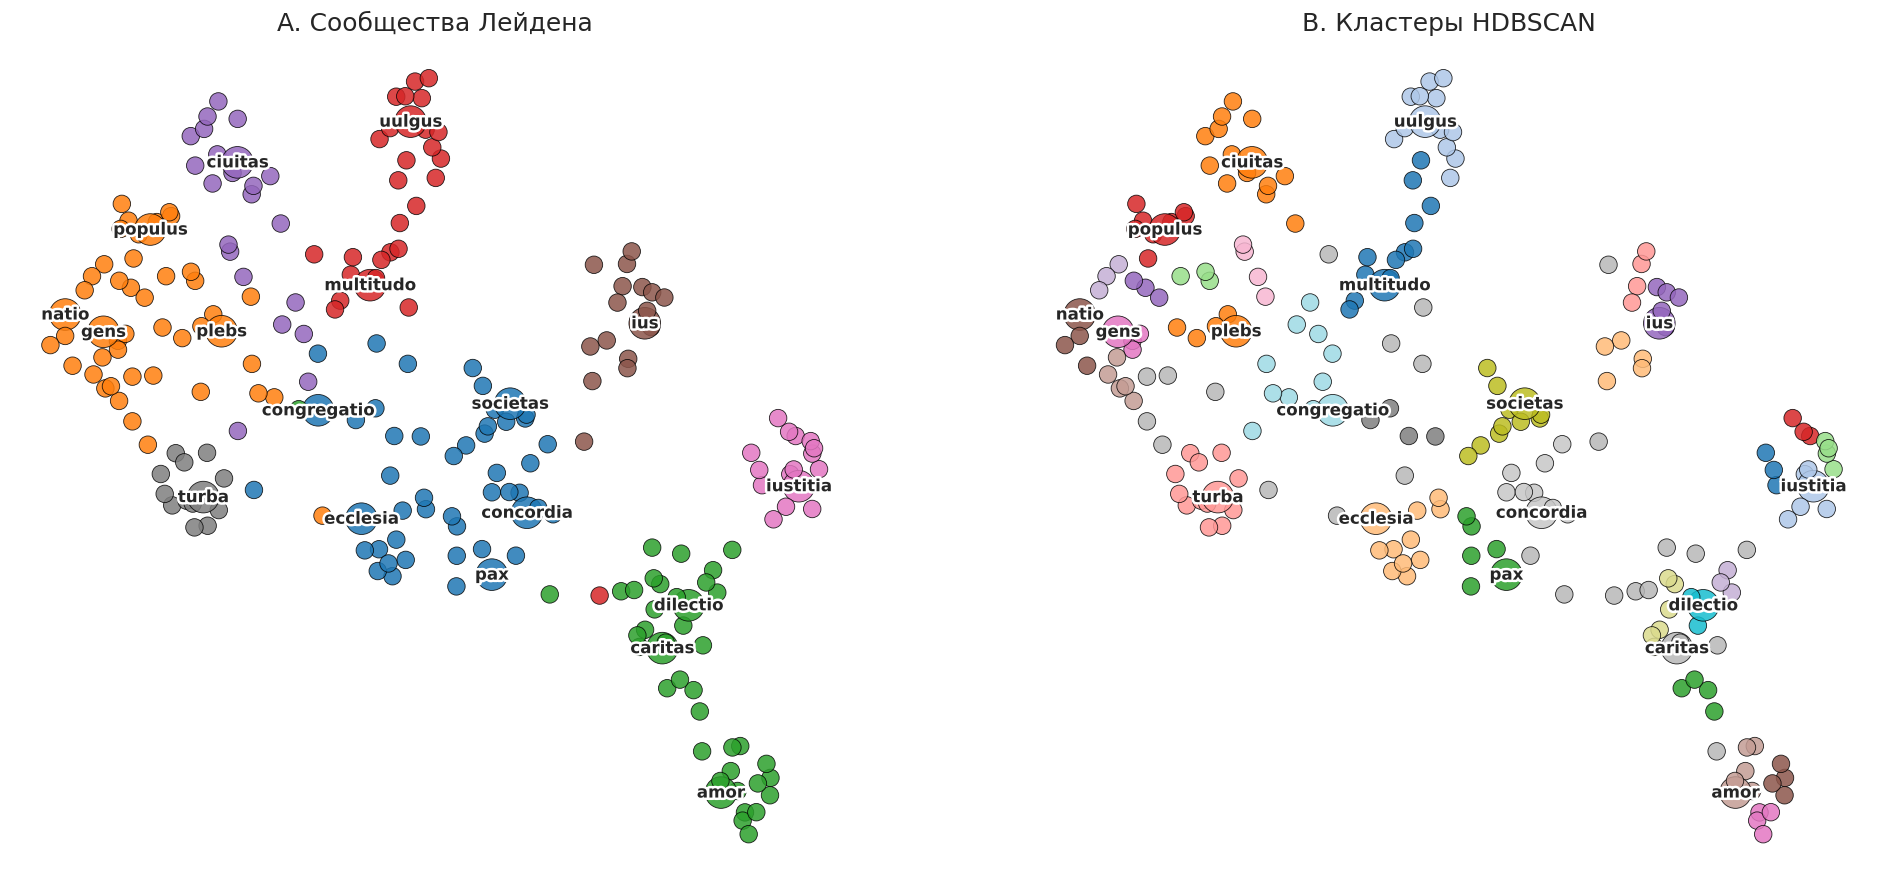

Сохранено: figures/Fig4_umap_leiden_hdbscan.png


In [6]:
graph = base["graph"]
lemmas = list(graph.nodes)
vectors = np.array([wv[w] for w in lemmas])
communities = article_numbering(leiden(graph, SEED))
leiden_labels = np.array([communities[w] for w in lemmas])

coords = umap.UMAP(n_neighbors=15, min_dist=0.3, metric="cosine",
                   random_state=SEED).fit_transform(vectors)
hdbscan_labels = HDBSCAN(min_cluster_size=3, min_samples=HDBSCAN_MIN_SAMPLES).fit_predict(coords)

print("Сообществ Лейдена:", len(set(leiden_labels)))
print("Кластеров HDBSCAN:", len(set(hdbscan_labels) - {-1}))
print("Точек, отнесённых к шуму:", int((hdbscan_labels == -1).sum()))

fig = draw_umap_panels(coords, lemmas, leiden_labels, hdbscan_labels)
save_figure(fig, "Fig4_umap_leiden_hdbscan")

## 7. UMAP и HDBSCAN: 120 проекций

Одна проекция может оказаться случайной, поэтому проверка повторяется: 3 значения `n_neighbors` × 2 значения `min_dist` × 20 случайных инициализаций = 120 проекций; к каждой применяется HDBSCAN с минимальным размером кластера 3 и 5. Для каждой проекции фиксируется:

- **trustworthiness** — насколько ближайшие соседи на плоскости являются соседями и в исходном пространстве (1 — полное совпадение);
- **однородность** и **полнота** — совпадают ли кластеры HDBSCAN с сообществами Лейдена. Высокая однородность при меньшей полноте означает, что кластеры HDBSCAN дробят сообщества, но не смешивают их;
- ближе ли *gens, natio* и *plebs* к *populus*, чем леммы права, любви, согласия и церковной общности.

Дополнительно вычисляется силуэт разбиения Лейдена в исходном пространстве (без проекции) и сравнивается со случайными перестановками. Расчёт занимает несколько минут.

In [7]:
# Силуэт в исходном пространстве косинусных расстояний
unit = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
distances = np.clip(1 - unit @ unit.T, 0, None)
np.fill_diagonal(distances, 0)
silhouette = silhouette_score(distances, leiden_labels, metric="precomputed")
rng = np.random.default_rng(0)
silhouette_random = max(silhouette_score(distances, rng.permutation(leiden_labels), metric="precomputed")
                        for _ in range(N_PERMUTATIONS))
print(f"Силуэт разбиения Лейдена: {silhouette:.3f}; "
      f"максимум при {N_PERMUTATIONS} случайных перестановках: {silhouette_random:.3f}")

# 120 проекций
index = {w: i for i, w in enumerate(lemmas)}
close = ["gens", "natio", "plebs"]
projections, clusterings = [], []
for nn, md_, seed in itertools.product(UMAP_NEIGHBORS, UMAP_MIN_DIST, range(UMAP_SEEDS)):
    xy = umap.UMAP(n_neighbors=nn, min_dist=md_, metric="cosine", random_state=seed).fit_transform(vectors)
    d = np.linalg.norm(xy - xy[index["populus"]], axis=1)       # расстояния до populus на плоскости
    nearest_targets = sorted((t for t in TARGET_TERMS if t != "populus"), key=lambda t: d[index[t]])[:3]
    projections.append({
        "trustworthiness": trustworthiness(vectors, xy, n_neighbors=10, metric="cosine"),
        "gens, natio, plebs ближе": max(d[index[t]] for t in close) < min(d[index[t]] for t in SEPARATE_FROM_POPULUS),
        "отношение расстояний": np.mean([d[index[t]] for t in SEPARATE_FROM_POPULUS]) / np.mean([d[index[t]] for t in close]),
        **{f"{t} среди трёх ближайших": t in nearest_targets for t in ["ciuitas", "congregatio", "turba"]},
    })
    for mcs in HDBSCAN_MIN_CLUSTER:
        labels = HDBSCAN(min_cluster_size=mcs, min_samples=HDBSCAN_MIN_SAMPLES).fit_predict(xy)
        ok = labels >= 0
        h, c, _ = homogeneity_completeness_v_measure(leiden_labels[ok], labels[ok])
        clusterings.append({"min_cluster_size": mcs, "кластеров": labels.max() + 1,
                            "шум": int((~ok).sum()), "однородность": h, "полнота": c,
                            "populus и gens в одном кластере":
                                labels[index["populus"]] >= 0 and labels[index["populus"]] == labels[index["gens"]]})

projections = pd.DataFrame(projections)
clusterings = pd.DataFrame(clusterings)

display(Markdown("**Проекции UMAP (120)**"))
display(pd.DataFrame({
    "Показатель": ["trustworthiness (мин.–макс.)",
                   "gens, natio, plebs ближе к populus, чем лексика права, любви и Церкви",
                   "отношение средних расстояний (мин. / медиана / макс.)",
                   "ciuitas среди трёх целевых лемм, ближайших к populus",
                   "congregatio среди трёх ближайших", "turba среди трёх ближайших"],
    "Значение": [f"{projections['trustworthiness'].min():.3f}–{projections['trustworthiness'].max():.3f}",
                 f"{projections['gens, natio, plebs ближе'].sum()} из {len(projections)}",
                 " / ".join(f"{x:.1f}" for x in projections["отношение расстояний"].quantile([0, .5, 1])),
                 f"{projections['ciuitas среди трёх ближайших'].mean():.0%}",
                 f"{projections['congregatio среди трёх ближайших'].mean():.0%}",
                 f"{projections['turba среди трёх ближайших'].mean():.0%}"]}).set_index("Показатель"))

display(Markdown("**Кластеризации HDBSCAN (медианы и доли)**"))
display(clusterings.groupby("min_cluster_size").agg(
    кластеров_медиана=("кластеров", "median"), кластеров_мин=("кластеров", "min"),
    кластеров_макс=("кластеров", "max"), шум_медиана=("шум", "median"),
    однородность_медиана=("однородность", "median"), полнота_медиана=("полнота", "median"),
    populus_с_gens=("populus и gens в одном кластере", "mean")).round(3))

Силуэт разбиения Лейдена: 0.184; максимум при 1000 случайных перестановках: -0.047


**Проекции UMAP (120)**

,Значение
Показатель,
trustworthiness (мин.–макс.),0.944–0.964
"gens, natio, plebs ближе к populus, чем лексика права, любви и Церкви",120 из 120
отношение средних расстояний (мин. / медиана / макс.),4.3 / 5.8 / 8.9
"ciuitas среди трёх целевых лемм, ближайших к populus",72%
congregatio среди трёх ближайших,5%
turba среди трёх ближайших,0%


**Кластеризации HDBSCAN (медианы и доли)**

,кластеров_медиана,кластеров_мин,кластеров_макс,шум_медиана,однородность_медиана,полнота_медиана,populus_с_gens
min_cluster_size,,,,,,,
3,32.0,22,44,27.0,0.953,0.577,0.042
5,17.0,12,22,16.5,0.930,0.686,0.233


## 8. Итог: табл. П2

Сводная таблица собирает результаты разделов 4–7 в том виде, в каком они приведены в табл. П2 Приложения.

In [8]:
def per_n(*terms):
    return " / ".join(str(sum(counts[n][t] for t in terms)) for n in TOP_N_VALUES)

h_med = clusterings.groupby("min_cluster_size")["однородность"].median()
c_med = clusterings.groupby("min_cluster_size")["полнота"].median()
ratio = projections["отношение расстояний"]

summary = pd.DataFrame([
    ("gens в сообществе populus", per_n("gens"),
     f"ближе к populus, чем лексика права, любви и Церкви, в {projections['gens, natio, plebs ближе'].sum()} из 120"),
    ("natio в сообществе populus", per_n("natio"), "то же"),
    ("plebs в сообществе populus", per_n("plebs"), "то же"),
    ("ius, iustitia, amor, caritas, dilectio, concordia, pax, ecclesia в сообществе populus",
     per_n("ius", "iustitia", "amor", "caritas", "dilectio", "concordia", "pax", "ecclesia"),
     f"среднее расстояние от populus в {ratio.min():.1f}–{ratio.max():.1f} раза больше, чем до gens, natio, plebs"),
    ("ciuitas в сообществе populus", per_n("ciuitas"),
     f"среди трёх ближайших к populus в {projections['ciuitas среди трёх ближайших'].mean():.0%} проекций"),
    ("congregatio в сообществе populus", per_n("congregatio"),
     f"то же, в {projections['congregatio среди трёх ближайших'].mean():.0%}"),
    ("turba в сообществе populus", per_n("turba"),
     f"то же, в {projections['turba среди трёх ближайших'].mean():.0%}"),
    ("Кластеры HDBSCAN и сообщества Лейдена", "–",
     f"однородность {h_med.min():.2f}–{h_med.max():.2f}, полнота {c_med.min():.2f}–{c_med.max():.2f} (медианы)"),
], columns=["Наблюдение", f"Лейден: запусков из {N_LEIDEN_RUNS} (N = 10 / 15 / 20)", "UMAP/HDBSCAN (120 проекций)"])

display(Markdown("**Таблица П2. Сводка проверок устойчивости**"))
display(summary.set_index("Наблюдение"))
print(f"При θ = {next_threshold} первой отделяется компонента: {', '.join(t for t in TARGET_TERMS if t in detached)} "
      f"и её окружение ({len(detached)} лемм).")

**Таблица П2. Сводка проверок устойчивости**

,Лейден: запусков из 50 (N = 10 / 15 / 20),UMAP/HDBSCAN (120 проекций)
Наблюдение,,
gens в сообществе populus,42 / 49 / 50,"ближе к populus, чем лексика права, любви и Це..."
natio в сообществе populus,42 / 49 / 50,то же
plebs в сообществе populus,50 / 47 / 50,то же
"ius, iustitia, amor, caritas, dilectio, concordia, pax, ecclesia в сообществе populus",0 / 0 / 0,среднее расстояние от populus в 4.3–8.9 раза б...
ciuitas в сообществе populus,10 / 6 / 4,среди трёх ближайших к populus в 72% проекций
congregatio в сообществе populus,28 / 0 / 1,"то же, в 5%"
turba в сообществе populus,2 / 0 / 19,"то же, в 0%"
Кластеры HDBSCAN и сообщества Лейдена,–,"однородность 0.93–0.95, полнота 0.58–0.69 (мед..."


При θ = 0.48 первой отделяется компонента: iustitia и её окружение (16 лемм).
